# Simple PCA

Use the  library to fetch the **last 2 years** of daily prices for the most-liquid US common stocks, pack them into a NumPy matrix, then explore **which stocks are similar in PCA space**.

Run from the repo root with the project env active so  is importable in editable mode.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stonks import get_prices, load_universe

%matplotlib inline


## Parameters

- `PERIOD`: history window — last 2 years.
- `TOP_N`: how many of the most-liquid stocks to keep.
- `FIELD`: which OHLCV field (`close` is split/dividend adjusted).

> The first call for a given `period`/`interval` downloads the entire common-stock universe and ranks it by traded dollar volume — expect a couple of minutes. It's cached to `data/`, so afterwards changing `TOP_N` or `FIELD` is instant.


In [2]:
PERIOD = "2y"
INTERVAL = "1d"
TOP_N = 50          # bump to 1500 for the full set (free after the first run caches the universe)
FIELD = "close"


## Fetch prices


In [3]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval=INTERVAL, field=FIELD)
prices


Date,2024-08-13,2024-08-14,2024-08-15,2024-08-16,2024-08-19,2024-08-20,2024-08-21,2024-08-22,2024-08-23,2024-08-26,...,2026-07-31,2026-08-03,2026-08-04,2026-08-05,2026-08-06,2026-08-07,2026-08-10,2026-08-11,2026-08-12,2026-08-13
ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,115.948898,117.885704,122.657829,124.375008,129.786087,127.040604,128.288574,123.536377,129.157135,126.251907,...,200.750000,206.639999,211.940002,219.220001,218.990005,223.960007,217.550003,217.500000,224.089996,225.789993
TSLA,207.830002,201.380005,214.139999,216.119995,222.720001,221.100006,223.270004,210.660004,220.320007,213.210007,...,311.209991,322.079987,327.350006,321.549988,319.529999,328.579987,330.880005,332.809998,327.510010,338.174988
SPCX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,108.370003,114.529999,125.330002,108.269997,114.919998,133.110001,138.740005,133.289993,146.149994,142.239899
AAPL,219.434372,219.880646,222.855759,224.174713,224.016068,224.630920,224.521805,222.667358,224.958191,225.295364,...,308.643829,303.158569,309.113403,310.732025,312.140808,313.059998,308.260010,304.910004,302.250000,303.440002
MU,96.831024,99.782455,106.281570,107.315079,107.951088,107.315079,107.652954,103.608391,102.207207,98.291832,...,823.030029,829.500000,892.669983,893.190002,881.469971,877.570007,861.000000,868.520020,911.289978,966.780029
MSFT,407.604218,410.410126,415.262695,412.737732,415.755859,418.981079,418.330109,409.857727,411.080811,407.825958,...,464.720001,487.649994,492.809998,487.459991,499.859985,499.989990,506.059998,503.809998,492.429993,494.989990
AMZN,170.229996,170.100006,177.589996,177.059998,178.220001,178.880005,180.110001,176.130005,177.039993,175.500000,...,271.579987,284.019989,277.420013,272.649994,272.260010,274.480011,278.089996,272.269989,267.279999,265.915009
META,525.015686,523.247498,533.747070,523.903076,525.750732,523.217651,531.591492,528.383057,524.479309,517.645203,...,556.710022,590.239990,587.940002,588.770020,589.900024,592.099976,594.919983,599.119995,578.849976,589.474976
AMD,141.130005,140.750000,147.360001,148.559998,155.279999,156.399994,157.809998,151.699997,154.979996,149.990005,...,476.149994,484.640015,518.580017,482.049988,489.279999,483.359985,469.559998,474.320007,482.929993,491.230011


The result is an **N×T** DataFrame: rows are tickers (N), columns are dates (T). Some rows contain `NaN` (recently delisted / thinly traded names) — drop them for a clean matrix.


In [4]:
prices_clean = prices.dropna()
X = prices_clean.to_numpy(dtype=float)
tickers = list(prices_clean.index)
scale = np.sqrt(len(tickers))   # sqrt(N): unit-variance loadings (~ N(0,1) under noise)

print("X.shape:", X.shape, "| N stocks:", len(tickers))


X.shape: (45, 502) | N stocks: 45


Text(0, 0.5, 'price')

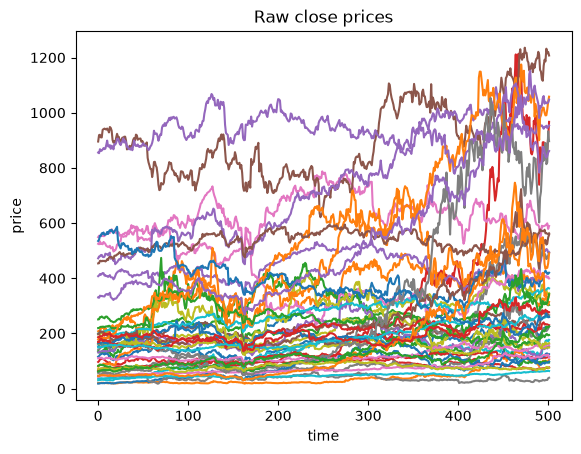

In [5]:
plt.plot(X.T)
plt.title("Raw close prices"); plt.xlabel("time"); plt.ylabel("price")


## Centre & covariance

Centre each stock's series by its own mean (remove the level, keep the shape), then build the stock×stock covariance, normalised by **T** (the time axis).


Text(0, 0.5, 'centred price')

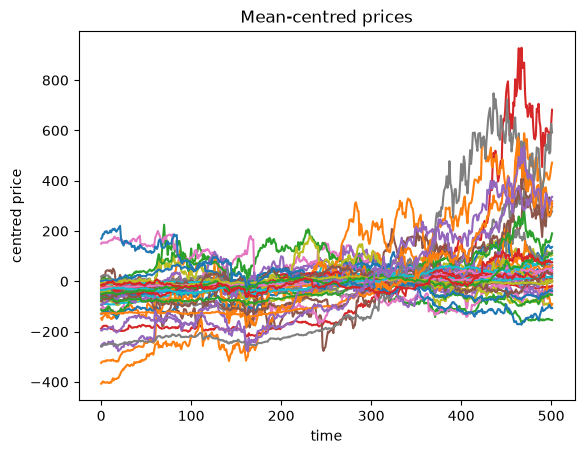

In [6]:
X_centered = X - X.mean(axis=1, keepdims=True)
plt.plot(X_centered.T)
plt.title("Mean-centred prices"); plt.xlabel("time"); plt.ylabel("centred price")


Text(0, 0.5, 'stock')

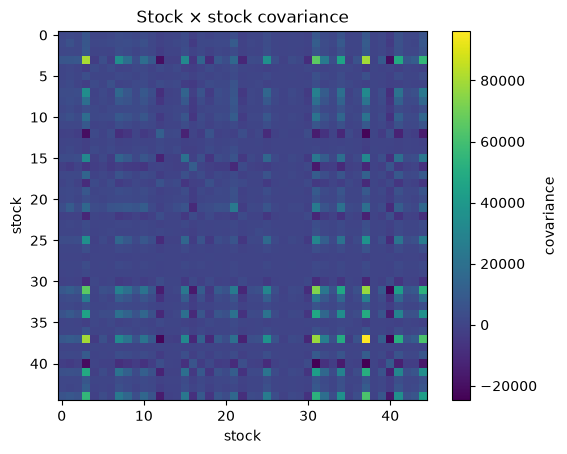

In [7]:
cov = (X_centered @ X_centered.T) / X_centered.shape[1]

plt.imshow(cov)
plt.colorbar(label="covariance")
plt.title("Stock × stock covariance"); plt.xlabel("stock"); plt.ylabel("stock")


## PCA via SVD

`cov` is symmetric positive-semidefinite, so decompose with **SVD** (equivalently `eigh`). Never `np.linalg.eig` — on a symmetric matrix it returns a complex dtype with tiny imaginary noise.


In [8]:
U, S, Vt = np.linalg.svd(cov)
print("top singular values:", np.round(S[:5], 3))


top singular values: [429557.801  52426.313  16229.861  12401.378   6443.429]


## Stocks in PCA space

Because `cov` is N×N over **stocks**, each eigenvector `U[:,k]` is an N-vector with one entry per stock — so `(U[i,0], U[i,1])` is stock *i*'s coordinate on PC1/PC2. We scale the loadings by `sqrt(N)` so that under a pure-noise (random) covariance the components are unit-variance, i.e. `~N(0,1)` — the **random-matrix-theory null**: a tight Gaussian blob ⇒ noise eigenvector, outliers ⇒ a real factor.


In [9]:
uni = load_universe()
NAMES = dict(zip(uni["ticker"], uni["name"]))

def label(t: str) -> str:
    return f"{t} ({NAMES.get(t, '')[:22]})"


Text(0.5, 1.0, 'Stocks in PCA space (top 2 components)')

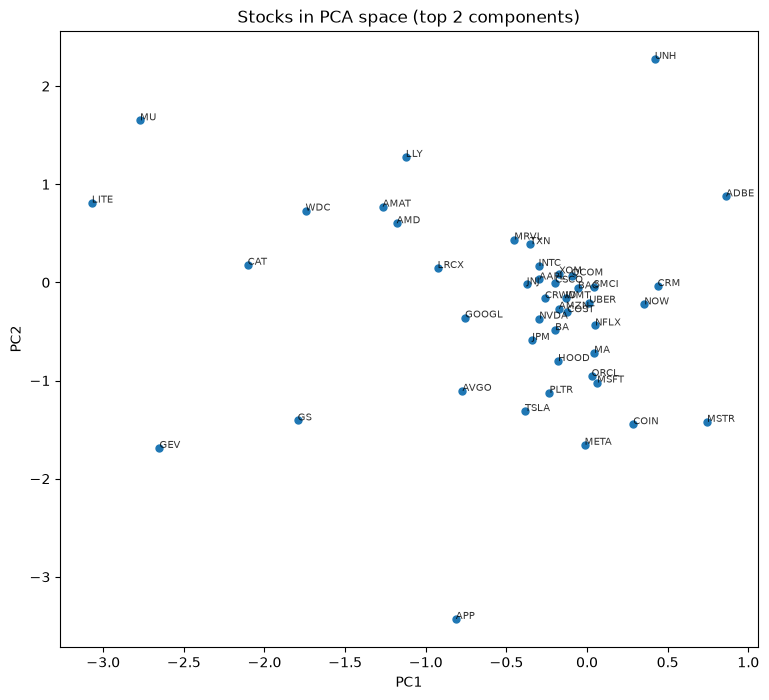

In [10]:
coords = U[:, :2] * scale   # sqrt(N)-scaled => unit-variance loadings
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=25)
for i, t in enumerate(tickers):
    ax.annotate(t, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Stocks in PCA space (top 2 components)")


## Which stocks are similar?

Similarity = Euclidean distance in the top-`k` PCA space (same `sqrt(N)` scaling). Note: this scaling is just a uniform factor on the coordinates, so the *ranking* of nearest neighbours is unchanged by it — but it keeps the distances in the unit-variance (chi-square-like) units of the RMT null.


In [11]:
k = 5  # number of PCs used to define similarity
Z = U[:, :k] * scale
D = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
np.fill_diagonal(D, np.inf)  # ignore self

iu = np.triu_indices(len(tickers), k=1)
print("most similar pairs:")
for r in np.argsort(D[iu])[:10]:
    i, j = iu[0][r], iu[1][r]
    print(f"  d={D[i, j]:.3f}  {label(tickers[i]):30s} ~ {label(tickers[j])}")


most similar pairs:
  d=0.213  SMCI (Super Micro Computer, )  ~ UBER (Uber Technologies, Inc)
  d=0.255  SMCI (Super Micro Computer, )  ~ BAC (Bank of America Corpor)
  d=0.276  BAC (Bank of America Corpor)   ~ CSCO (Cisco Systems, Inc. - )
  d=0.284  WMT (Walmart Inc. - Common )   ~ XOM (ExxonMobil Holdings Co)
  d=0.293  SMCI (Super Micro Computer, )  ~ CSCO (Cisco Systems, Inc. - )
  d=0.323  BAC (Bank of America Corpor)   ~ UBER (Uber Technologies, Inc)
  d=0.352  INTC (Intel Corporation - Co)  ~ CSCO (Cisco Systems, Inc. - )
  d=0.373  JPM (JP Morgan Chase & Co. )   ~ HOOD (Robinhood Markets, Inc)
  d=0.386  WMT (Walmart Inc. - Common )   ~ BAC (Bank of America Corpor)
  d=0.396  NVDA (NVIDIA Corporation - C)  ~ BAC (Bank of America Corpor)


In [12]:
target = "AAPL"
i = tickers.index(target)
j = int(D[i].argmin())
print(f"{label(target)}'s nearest neighbour: {label(tickers[j])}  (d={D[i, j]:.3f})")


AAPL (Apple Inc. - Common St)'s nearest neighbour: QCOM (QUALCOMM Incorporated )  (d=0.608)


### Refinement: returns instead of prices

Above uses centred *prices*, so PC1 mostly captures overall trajectory shape. To cluster by co-movement (more sector-like), rebuild the covariance from log-returns:

```python
R = np.log(prices_clean / prices_clean.shift(axis=1))
X_centered = R.dropna(axis=1, how="all").fillna(0.0).to_numpy(dtype=float)
# then rerun the covariance / SVD / distance cells
```

The full RMT treatment also compares the eigenvalue spectrum to the **Marchenko–Pastur** bounds to label which eigenvalues are signal vs noise (works cleanly on a *correlation* matrix, so standardise the returns first).
